# PBA Week 7 — Clustering, Sentiment, POS Tagging & NER
Data: `preprocessed_articles.csv` (output of `preprocess.py`)

## 1. Setup & Imports

In [13]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Load Data

In [14]:
df = pd.read_csv('preprocessed_articles.csv')
print(f"Loaded {len(df)} articles")
print(f"Columns: {list(df.columns)}")
df.head(3)

Loaded 340 articles
Columns: ['judul', 'link', 'portal_berita', 'text_berita', 'text_berita_clean']


,judul,link,portal_berita,text_berita,text_berita_clean
0,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,https://tribratanews.polri.go.id/blog/nasional...,Tribrata,Tribratanews.polri.go.id– Jakarta. Wakil Mente...,tribratanews polri go id jakarta wakil menteri...
1,Makan Gratis dan Pertaruhan Politik Anggaran |...,https://www.tempo.co/kolom/mbg-dan-pertaruhan-...,Tempo,Iklan\nBerita Tempo Plus\nHandi Risza\nWakil R...,wakil rektor universitas paramadina lulus prog...
2,Pedagang Melon di Pasar Gede Solo Rasakan Peni...,https://www.liputan6.com/regional/read/6310544...,Liputan6,"Pedagang buah di Pasar Gede Hardjonagoro Solo,...",dagang buah pasar gede hardjonagoro solo rasa ...


## 3. Vectorization & Clustering

We evaluate **TF-IDF**, **Bag-of-Words**, and **Cosine Similarity** with KMeans (k=3).
Metrics: Silhouette, Calinski-Harabasz, Davies-Bouldin.

In [15]:
texts = df['text_berita_clean'].fillna('').tolist()
N_CLUSTERS = 3

vectorizers = {
    'TF-IDF':          TfidfVectorizer(max_features=5000),
    'Bag-of-Words':    CountVectorizer(max_features=5000),
}

matrices = {}
cluster_labels = {}
metrics_rows = []

for name, vec in vectorizers.items():
    X = vec.fit_transform(texts)
    matrices[name] = X

    km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    cluster_labels[name] = labels

    metrics_rows.append({
        'Method':             name,
        'Silhouette':         round(silhouette_score(X, labels), 4),
        'Calinski-Harabasz':  round(calinski_harabasz_score(X.toarray(), labels), 4),
        'Davies-Bouldin':     round(davies_bouldin_score(X.toarray(), labels), 4),
    })

# Cosine similarity variant (from TF-IDF matrix)
cos_sim = cosine_similarity(matrices['TF-IDF'])
km_cos = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels_cos = km_cos.fit_predict(cos_sim)
cluster_labels['Cosine Similarity'] = labels_cos
metrics_rows.append({
    'Method':             'Cosine Similarity',
    'Silhouette':         round(silhouette_score(cos_sim, labels_cos), 4),
    'Calinski-Harabasz':  round(calinski_harabasz_score(cos_sim, labels_cos), 4),
    'Davies-Bouldin':     round(davies_bouldin_score(cos_sim, labels_cos), 4),
})

pd.DataFrame(metrics_rows).set_index('Method')

,Silhouette,Calinski-Harabasz,Davies-Bouldin
Method,,,
TF-IDF,0.0262,8.0972,5.2401
Bag-of-Words,0.6111,72.0058,1.1939
Cosine Similarity,0.1461,50.7116,2.0090


## 4. Optimal K — WCSS Elbow Method

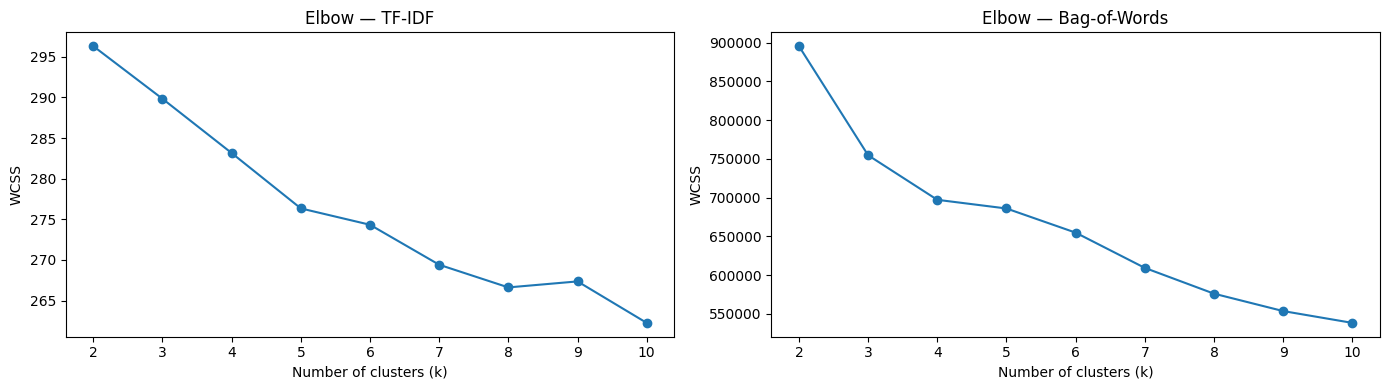

In [16]:
K_RANGE = range(2, 11)
fig, axes = plt.subplots(1, len(vectorizers), figsize=(14, 4), sharey=False)

for ax, (name, X) in zip(axes, matrices.items()):
    wcss = [
        KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_
        for k in K_RANGE
    ]
    ax.plot(list(K_RANGE), wcss, marker='o')
    ax.set_title(f'Elbow — {name}')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('WCSS')

plt.tight_layout()
plt.show()

## 5. Sentiment Analysis

In [17]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:
        return polarity, 'Positive'
    elif polarity < -0.1:
        return polarity, 'Negative'
    return polarity, 'Neutral'

df[['sentiment_score', 'sentiment_label']] = df['text_berita'].apply(
    lambda t: pd.Series(get_sentiment(t))
)

# Attach cluster labels from TF-IDF (best default)
df['cluster'] = cluster_labels['TF-IDF']

print(df['sentiment_label'].value_counts())
df[['judul', 'sentiment_score', 'sentiment_label', 'cluster']].head(5)

sentiment_label
Neutral     251
Positive     74
Negative     15
Name: count, dtype: int64


,judul,sentiment_score,sentiment_label,cluster
0,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,0.000000,Neutral,0
1,Makan Gratis dan Pertaruhan Politik Anggaran |...,0.000000,Neutral,0
2,Pedagang Melon di Pasar Gede Solo Rasakan Peni...,0.285714,Positive,0
3,"Melihat Praktik Kyushoku, Program MBG di Jepan...",0.445833,Positive,0
4,Anak Bukan Angka: Kritik Ibu atas Program Maka...,-0.125000,Negative,0


## 6. Visualizations

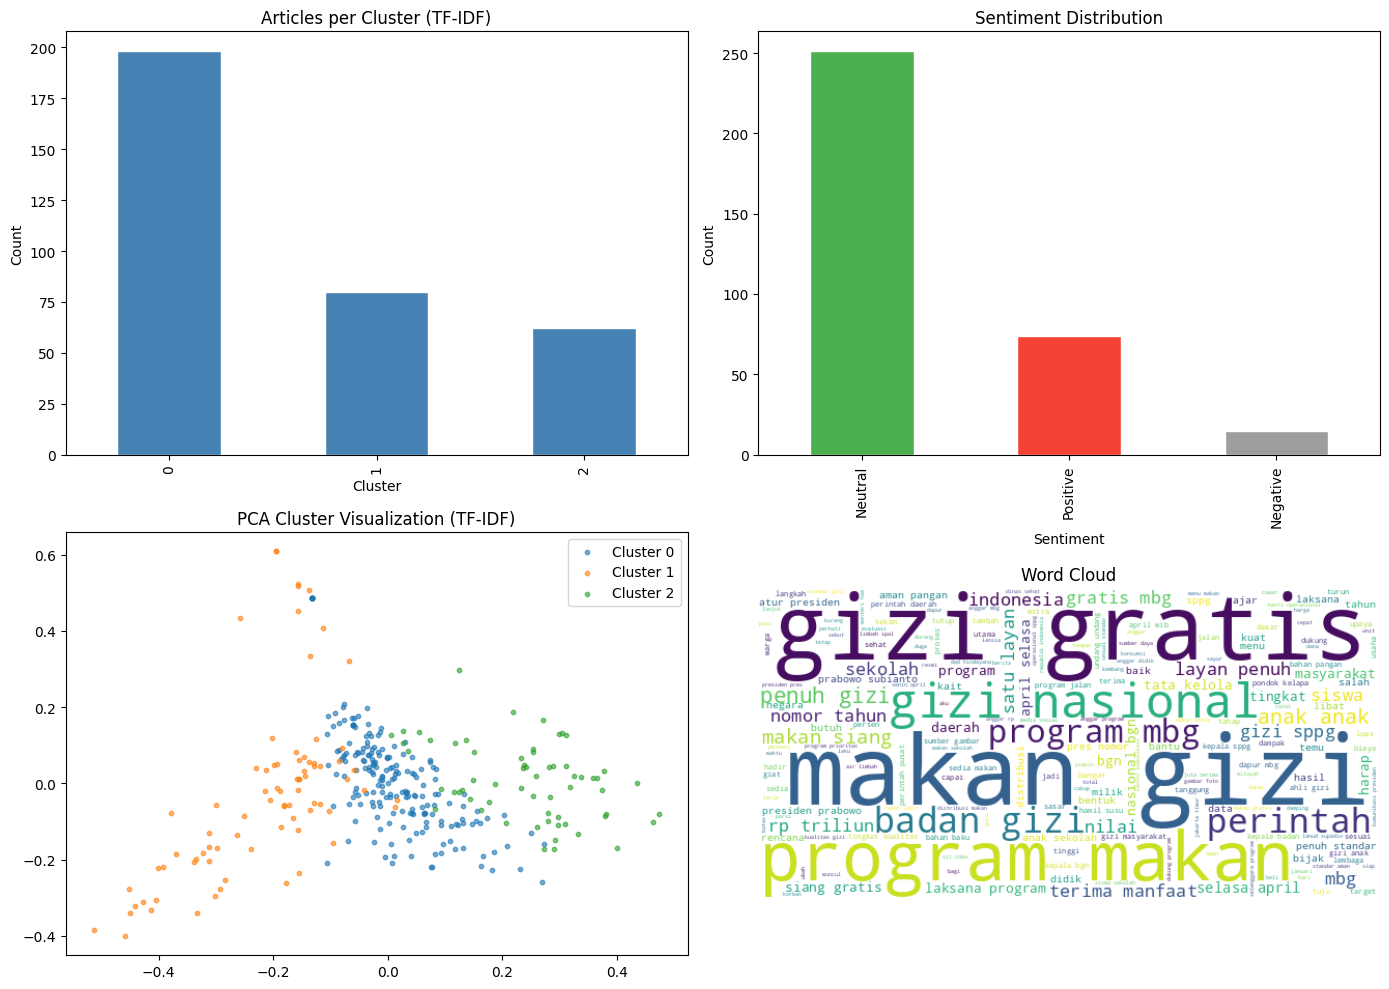

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Cluster distribution ---
df['cluster'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='white'
)
axes[0, 0].set_title('Articles per Cluster (TF-IDF)')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Count')

# --- Sentiment distribution ---
df['sentiment_label'].value_counts().plot(
    kind='bar', ax=axes[0, 1],
    color=['#4caf50', '#f44336', '#9e9e9e'], edgecolor='white'
)
axes[0, 1].set_title('Sentiment Distribution')
axes[0, 1].set_xlabel('Sentiment')
axes[0, 1].set_ylabel('Count')

# --- PCA cluster scatter (TF-IDF) ---
X_2d = PCA(n_components=2, random_state=42).fit_transform(
    matrices['TF-IDF'].toarray()
)
for c in range(N_CLUSTERS):
    mask = df['cluster'] == c
    axes[1, 0].scatter(X_2d[mask, 0], X_2d[mask, 1], label=f'Cluster {c}', s=10, alpha=0.6)
axes[1, 0].set_title('PCA Cluster Visualization (TF-IDF)')
axes[1, 0].legend()

# --- Word cloud from all clean text ---
all_text = ' '.join(df['text_berita_clean'].dropna())
wc = WordCloud(width=600, height=300, background_color='white').generate(all_text)
axes[1, 1].imshow(wc, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('Word Cloud')

plt.tight_layout()
plt.show()

## 7. POS Tagging (Stanza — Indonesian)

Requires: `uv add stanza`  
Indonesian model is downloaded automatically on first run.

Total POS-tagged tokens: 223767

Top 15 POS tags:
NOUN     50179
PROPN    45777
PUNCT    33040
VERB     22753
ADP      16206
ADJ       9777
NUM       9310
PRON      8213
ADV       6419
DET       5863
CCONJ     5635
SCONJ     3952
AUX       3462
PART      2425
X          593
dtype: int64


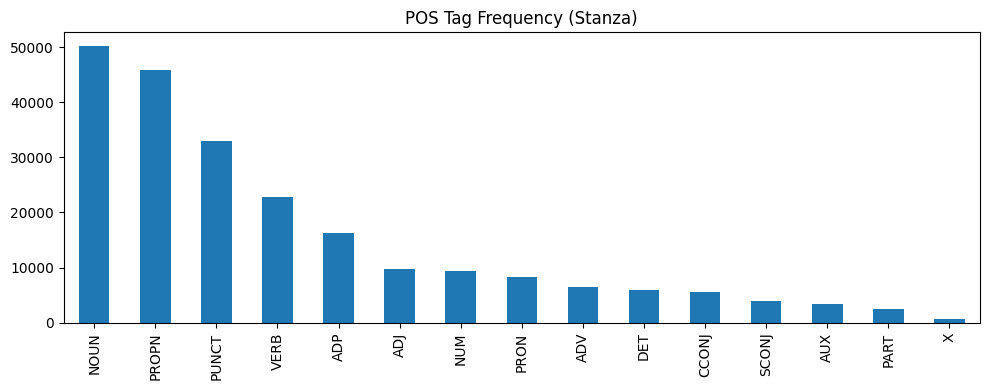

In [19]:
import stanza
from collections import Counter

stanza.download('id', verbose=False)  # no-op after first run
nlp = stanza.Pipeline('id', processors='tokenize,pos', verbose=False)

def extract_pos_tags(text):
    doc = nlp(str(text)[:10_000])  # cap per article to keep runtime reasonable
    return [(word.text, word.upos) for sent in doc.sentences for word in sent.words]

df['pos_tags'] = df['text_berita'].apply(extract_pos_tags)

# Flatten and count tag frequencies
all_tags = [tag for tags in df['pos_tags'] for _, tag in tags]
tag_counts = pd.Series(Counter(all_tags)).sort_values(ascending=False)

print(f"Total POS-tagged tokens: {len(all_tags)}")
print("\nTop 15 POS tags:")
print(tag_counts.head(15))

tag_counts.head(15).plot(kind='bar', figsize=(10, 4), title='POS Tag Frequency (Stanza)')
plt.tight_layout()
plt.show()

## 8. Named Entity Recognition (NER) — BERT Indonesian

Model: `cahya/bert-base-indonesian-NER`

In [9]:
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

MODEL_NAME = 'cahya/bert-base-indonesian-NER'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
ner_pipe  = pipeline('ner', model=model, tokenizer=tokenizer, aggregation_strategy='simple')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 37326.89it/s]
BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
MAX_CHARS   = 512 * 4   # rough char budget per chunk
STRIDE_CHARS = 256 * 4

def perform_ner(text):
    """Run NER on long text by sliding a window over character chunks."""
    text = str(text).strip()
    if not text:
        return []
    entities, seen = [], set()
    start = 0
    while start < len(text):
        chunk = text[start: start + MAX_CHARS]
        for ent in ner_pipe(chunk):
            key = (ent['word'], ent['entity_group'])
            if key not in seen:
                entities.append(ent)
                seen.add(key)
        start += STRIDE_CHARS
    return entities

def safe_perform_ner(text):
    try:
        return perform_ner(text)
    except Exception as e:
        return []

# Quick sanity check on first article
sample = safe_perform_ner(df['text_berita'].iloc[0])
print(f"Sample entities from article 0: {sample[:5]}")

Sample entities from article 0: [{'entity_group': 'NOR', 'score': np.float32(0.6493154), 'word': 'trib', 'start': 0, 'end': 4}, {'entity_group': 'ORG', 'score': np.float32(0.70221), 'word': '##ratanews.', 'start': 4, 'end': 13}, {'entity_group': 'NOR', 'score': np.float32(0.33491468), 'word': 'polri', 'start': 13, 'end': 18}, {'entity_group': 'ORG', 'score': np.float32(0.707932), 'word': 'go. id', 'start': 19, 'end': 24}, {'entity_group': 'GPE', 'score': np.float32(0.92852587), 'word': 'jakarta', 'start': 26, 'end': 33}]


In [11]:
print("Running NER on all articles (this may take a while)...")
df['ner_entities'] = df['text_berita'].apply(safe_perform_ner)

# Flatten to a summary column for readability
df['ner_summary'] = df['ner_entities'].apply(
    lambda ents: [(e['word'], e['entity_group']) for e in ents]
)

df[['judul', 'ner_summary']].head(5)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Running NER on all articles (this may take a while)...


,judul,ner_summary
0,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,"[(trib, NOR), (##ratanews., ORG), (polri, NOR)..."
1,Makan Gratis dan Pertaruhan Politik Anggaran |...,"[(berita, PRD), (tempo, ORG), (handi risza, PE..."
2,Pedagang Melon di Pasar Gede Solo Rasakan Peni...,"[(pasar gede hardjonagoro, LOC), (solo, GPE), ..."
3,"Melihat Praktik Kyushoku, Program MBG di Jepan...","[(bergi, EVT), (gratis, EVT), (mb, EVT), (##g,..."
4,Anak Bukan Angka: Kritik Ibu atas Program Maka...,"[(mb, EVT), (##g, PRD), (indonesia, GPE), (mb,..."


In [12]:
# Save full results
out_df = df[['judul', 'link', 'portal_berita', 'text_berita',
             'sentiment_score', 'sentiment_label', 'cluster', 'ner_summary']].copy()
out_df.to_csv('ner_results.csv', index=False)
print(f"Saved {len(out_df)} rows to ner_results.csv")

# Entity frequency across corpus
all_entities = [
    (e['word'], e['entity_group'])
    for ents in df['ner_entities'] for e in ents
]
entity_counts = pd.Series(Counter(all_entities)).sort_values(ascending=False)
print("\nTop 20 named entities:")
entity_counts.head(20)

Saved 340 rows to ner_results.csv

Top 20 named entities:


pemerintah           NOR    220
##g                  PRD    209
jakarta              GPE    164
mbg                  PRD    161
mb                   ORG    153
indonesia            GPE    136
badan gizi nasional  ORG    132
bgn                  ORG    131
satu                 CRD    119
mbg                  ORG    119
mb                   PRD    110
sppg                 ORG    107
spp                  PRD    107
1                    CRD    106
202                  CRD    105
##g                  ORG    104
prabowo              PER    102
mb                   EVT    100
2025                 DAT     97
presiden             NOR     97
dtype: int64